In [1]:
# --- Colab bootstrap -------------------------------------------------------
# No-op when you already have the thermo package alongside this notebook (the
# normal case: you cloned the repository and are running from code/chNN/).
# In Colab there is no repository, so fetch the package and the property data.
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    # rm -rf first: git clone REFUSES an existing directory, and under `!` that
    # failure is silent -- a half-finished earlier clone would otherwise leave an
    # empty thermo/ and surface as a baffling ImportError further down.
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')

# The axis labels below use the book's molar underbar, \underline{V}. With no
# LaTeX installed matplotlib falls back to its own mathtext engine, which only
# learned \underline in 3.11; Colab still ships 3.10.
from importlib.metadata import version

if tuple(map(int, version("matplotlib").split(".")[:2])) < (3, 11):
    !pip install -q "matplotlib>=3.11"
    if "matplotlib" in sys.modules:
        print("matplotlib upgraded - Runtime > Restart session, then Run all.")
# ---------------------------------------------------------------------------

# Example: Partial molar enthalpies from heat-of-mixing data (water + methanol)

**Generates Table 8.6-4 and Figure 8.6-3.**

The companion notebook,
[`RK_partial_molar_volume_water_methanol_example.ipynb`](RK_partial_molar_volume_water_methanol_example.ipynb),
took density data to partial molar volumes. This one takes calorimetry to partial molar
enthalpies, and the machinery is *identical* - Eqs. 8.6-10a,b are Eqs. 8.6-6a,b with
$\underline{V}$ replaced by $\underline{H}$:

$$\bar{H}_1 - \underline{H}_1 = \Delta_{\text{mix}}\underline{H} + x_2 \left(\frac{\partial \Delta_{\text{mix}}\underline{H}}{\partial x_1}\right)_{T,P}, \qquad
\bar{H}_2 - \underline{H}_2 = \Delta_{\text{mix}}\underline{H} - x_1 \left(\frac{\partial \Delta_{\text{mix}}\underline{H}}{\partial x_1}\right)_{T,P}$$

That `RedlichKister` needs no changes at all to do this is the point of Sec. 8.6's closing
generalization (Eq. 8.6-10): *any* molar property works the same way.

But the two calculations do **not** come out equally well, and the reason is worth knowing
before you start. The volume data are smooth, nearly symmetric, and the book supplies
fitted constants. The heat-of-mixing data are strongly **skewed** - the largest effect is
at $x_1 = 0.73$, not at $x_1 = 0.5$ - and no constants are published for them. A skewed
curve needs more terms, more terms make the endpoint derivatives less certain, and the
endpoints are exactly what the infinite-dilution rows of Table 8.6-4 report.

> **A production notebook.** Table 8.6-4 is a table the book prints, so there is one
> authoritative version of this calculation and no `_thermo` twin.

In [2]:
import sys
sys.path.append("..")           # so `import thermo` finds code/thermo

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Typography, matching the recomputed figures elsewhere in the book: a real LaTeX
# installation when there is one, matplotlib's own Computer Modern mathtext when
# there is not (Colab has no TeX).
from shutil import which

mpl.rcParams["text.usetex"] = which("latex") is not None
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

from thermo import RedlichKister, load_mixing_data

## The measurements

Table 8.6-3 comes from the *International Critical Tables* (1929) and reports $Q^{+}$, the
heat effect **per mole of methanol**, which is the natural quantity for a calorimeter run
that titrates water into methanol. The property we need is per mole of *mixture*:

$$\Delta_{\text{mix}}\underline{H} = Q = (1-x_1)\,Q^{+}$$

Check it. Like the density identity in the companion notebook, this is a relation the
table itself has to satisfy, and it is the only handle we have on whether the digits were
transcribed correctly.

In [3]:
d = load_mixing_data("water-methanol-enthalpy")
x1 = d["x1"].to_numpy()
x2 = 1.0 - x1
Qplus = d["Qplus_J_mol_MeOH"].to_numpy()
dmixH = d["dmixH_J_mol"].to_numpy()

print("identity  dmixH = (1 - x1) Q+")
print(f"  max|deviation| = {np.abs((1 - x1) * Qplus - dmixH).max():.3f} J/mol"
      f"   (table is printed to 1 J/mol)")
print()
print(f"most negative dmixH = {dmixH.min():.0f} J/mol at x1 = {x1[dmixH.argmin()]:.2f}")
print("(a symmetric heat of mixing would put it at x1 = 0.50)")

identity  dmixH = (1 - x1) Q+
  max|deviation| = 0.500 J/mol   (table is printed to 1 J/mol)

most negative dmixH = -917 J/mol at x1 = 0.70
(a symmetric heat of mixing would put it at x1 = 0.50)


The identity closes at the level of the printed rounding, and the skew is real: the
minimum sits at $x_1 = 0.70$-$0.75$ rather than at the midpoint. Water and methanol release
heat on mixing across the whole composition range, most strongly in methanol-poor
mixtures.

Note also what the table does *not* contain: rows at $x_1 = 0$ and $x_1 = 1$. The data span
0.05 to 0.95, so the infinite-dilution values that Table 8.6-4 reports are extrapolations
past the ends of the measurements.

## Choosing the order

There are no published constants here, so the order is our decision and we should make it
in the open. `scan_order` fits several and reports what each buys.

In [4]:
scan = RedlichKister.scan_order(x1, dmixH, orders=range(2, 8))

print("order   rms     LOO-rms   (H1bar-H1)_inf   (H2bar-H2)_inf      [J/mol]")
for s in scan:
    print(f"  {s['order']}   {s['rms']:6.2f}   {s['loo_rms']:6.2f}   "
          f"{s['inf_dilution_1']:12.1f}   {s['inf_dilution_2']:12.1f}")

order   rms     LOO-rms   (H1bar-H1)_inf   (H2bar-H2)_inf      [J/mol]
  2    17.22    20.37        -3480.4        -7686.8
  3     5.88     7.39        -2720.6        -8446.6
  4     4.54     6.18        -2449.8        -8175.8
  5     3.99     5.80        -2680.1        -7945.5
  6     2.79     4.87        -2246.5        -7511.8
  7     2.62     5.75        -2451.1        -7307.2


Two different stories in one table.

**The fit itself keeps improving.** The cross-validated error falls all the way to order 6
before turning up, so on interpolation grounds more terms really are earning their place
here - which is the skew asking for them. (Contrast the volume data, where order 3 was
already the bottom.)

**The endpoints do not settle at all.** $(\bar{H}_1-\underline{H}_1)^{\infty}$ ranges over
more than a kilojoule per mole across these orders, and it does not converge - it wanders.
Cross-validation cannot referee this, because every point it holds out is *interior*: it
measures interpolation, and the endpoints are extrapolations beyond the last datum at
$x_1 = 0.05$.

So we need a second criterion, and there is a physical one available. Each partial molar
excess must approach zero **monotonically** as its own species becomes pure: a species
cannot grow *more* unlike its pure self as its surroundings grow more like it. A fit that
turns over near an endpoint has put a wiggle where the data ran out. That is testable
without consulting any answer.

In [5]:
grid = np.round(np.arange(0.0, 1.0001, 0.05), 2)

print("order  LOO-rms   monotone to x1=1?   monotone to x1=0?")
for s in scan:
    e1, e2 = s["fit"].partial_molar_excess(grid)
    ok1 = bool(np.all(np.diff(e1) >= -1e-9))     # H1bar - H1 rises to zero
    ok2 = bool(np.all(np.diff(e2) <= 1e-9))      # H2bar - H2 falls from zero
    print(f"  {s['order']}    {s['loo_rms']:6.2f}      {str(ok1):>5}               {str(ok2):>5}")

order  LOO-rms   monotone to x1=1?   monotone to x1=0?
  2     20.37       True                True
  3      7.39       True                True
  4      6.18      False               False
  5      5.80       True                True
  6      4.87      False               False
  7      5.75      False               False


That settles it. Orders 4, 6 and 7 all fail - they turn over near an endpoint, putting a
bend in the curve where there is no data to justify one. Orders 3 and 5 pass, and of those
**order 5 has the lower cross-validated error**, so that is the correlation used for the
printed table.

Notice what just happened, because it generalizes well beyond this table. The best-fitting
model and the best-*behaved* model were not the same model, and the statistic that ranked
them could not see the difference. It took a physical requirement to break the tie.

In [6]:
ORDER = 5      # <- the modeling decision, in one place: lowest cross-validated
               #    error among the orders with monotone endpoint behavior

rk = RedlichKister.fit(x1, dmixH, order=ORDER)
print(rk)
print(f"\nrms residual = {rk.rms(x1, dmixH):.2f} J/mol")
print(f"largest single residual = {np.abs(rk.residuals(x1, dmixH)).max():.2f} J/mol")

RedlichKister(order=5, a=[-3239.97157 -1652.65784 -2630.56166 -1661.82537   557.73667   681.79922])

rms residual = 3.99 J/mol
largest single residual = 8.47 J/mol


The residual is a few joules per mole against data printed to one. That is not a
defect of the fit - it is a reminder that the printed precision of a 1929 calorimetry table
is not its accuracy. Three-figure agreement here is as much as the measurements support.

## Figure 8.6-3

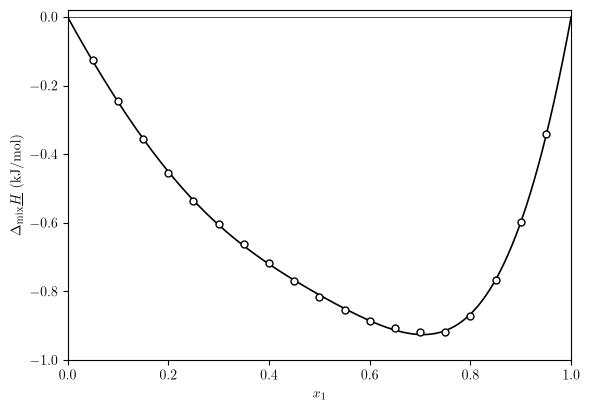

In [7]:
fig, ax = plt.subplots(figsize=(6.0, 4.2))

xs = np.linspace(0.0, 1.0, 400)
ax.plot(xs, rk(xs) / 1e3, "-", color="black", lw=1.2)
ax.plot(x1, dmixH / 1e3, "o", mfc="white", mec="black", ms=5, lw=0)

ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$\Delta_{\mathrm{mix}}\underline{H}$ (kJ/mol)")
ax.set_xlim(0, 1)
ax.set_ylim(-1.0, 0.02)
ax.axhline(0.0, color="black", lw=0.5)

fig.tight_layout()
os.makedirs("pdf", exist_ok=True)
fig.savefig("pdf/Fig_8.6-3.pdf")
plt.show()

## Table 8.6-4

The table is reported on a uniform 0.05 grid from 0 to 1 - so the two end rows are the
infinite-dilution values, computed by evaluating the correlation where there are no data.

The summation identity is checked again, and again it is exact by construction. Its value
here is different from the volume notebook's: it is what tells us this table is *internally
consistent with Table 8.6-3*, which a table built by drawing tangent lines on graph paper
cannot promise.

In [8]:
grid = np.round(np.arange(0.0, 1.0001, 0.05), 2)
g2 = 1.0 - grid

e1, e2 = rk.partial_molar_excess(grid)

table = pd.DataFrame({
    "x1": grid,
    "H1bar - H1": e1 / 1e3,
    "H2bar - H2": e2 / 1e3,
})

identity = np.abs(grid * e1 + g2 * e2 - rk(grid)).max()
print(f"summation identity (Eq. 8.1-15)  max|deviation| = {identity:.2e} J/mol\n")
print(table.to_string(index=False, float_format=lambda v: f"{v:9.3f}"))
print("\nall entries kJ/mol;  the x1 = 0 and x1 = 1 rows are infinite-dilution values")

summation identity (Eq. 8.1-15)  max|deviation| = 2.27e-13 J/mol

       x1  H1bar - H1  H2bar - H2
    0.000      -2.680      -0.000
    0.050      -2.476      -0.005
    0.100      -2.285      -0.021
    0.150      -2.088      -0.049
    0.200      -1.888      -0.092
    0.250      -1.697      -0.147
    0.300      -1.532      -0.209
    0.350      -1.404      -0.271
    0.400      -1.314      -0.324
    0.450      -1.258      -0.365
    0.500      -1.223      -0.397
    0.550      -1.191      -0.432
    0.600      -1.143      -0.498
    0.650      -1.063      -0.632
    0.700      -0.942      -0.888
    0.750      -0.777      -1.326
    0.800      -0.580      -2.010
    0.850      -0.372      -2.998
    0.900      -0.184      -4.327
    0.950      -0.049      -5.997
    1.000      -0.000      -7.945

all entries kJ/mol;  the x1 = 0 and x1 = 1 rows are infinite-dilution values


Read the two columns against each other. Each species' partial molar enthalpy
approaches its pure-component value as its own mole fraction approaches one, and departs
furthest from it at infinite dilution - the same pattern as the volumes, for the same
physical reason. The methanol column is much the larger of the two, because a methanol
molecule dropped into pure water is in a far more foreign environment than a water molecule
dropped into pure methanol.

In [9]:
os.makedirs("output", exist_ok=True)
table.to_csv("output/Table_8.6-4.csv", index=False)

with open("output/Table_8.6-4.txt", "w") as fh:
    fh.write("Table 8.6-4  The Difference between the Partial Molar and Pure Component\n")
    fh.write("             Enthalpies for the Water(1)-Methanol(2) System at T = 19.69 C\n")
    fh.write(f"All entries kJ/mol.  Computed from Table 8.6-3 by a Redlich-Kister\n")
    fh.write(f"correlation of the heat of mixing, order {rk.order} "
             f"(Eqs. 8.6-5a, 8.6-10a, 8.6-10b).\n\n")
    fh.write(table.to_string(index=False, float_format=lambda v: f"{v:9.3f}"))
    fh.write("\n\nThe x1 = 0 and x1 = 1 rows are infinite-dilution values, obtained by\n"
             "evaluating the correlation outside the range of the data (0.05 to 0.95).\n")

print("wrote output/Table_8.6-4.csv and output/Table_8.6-4.txt")

wrote output/Table_8.6-4.csv and output/Table_8.6-4.txt


## Your turn

1. **Change one line.** Set `ORDER = 6` - the order with the *best* cross-validated error -
   and rerun. Fig. 8.6-3 will look no worse. Now look at the first two rows of
   Table 8.6-4. What went wrong, and why did the cross-validated error not warn you?

2. **Make the monotonicity test do the work.** Right now you read the pass/fail table and
   pick by eye. Write a few lines that scan the orders and return the best one
   automatically, then check that it still chooses 5 if you drop the $x_1 = 0.05$ and
   $x_1 = 0.95$ rows from the data.

3. **Where does the skew come from?** The one-constant Redlich-Kister expansion ($a_0$
   alone) is exactly symmetric about $x_1 = 0.5$. Fit it, plot it against the data, and
   identify which coefficient does the work of moving the minimum out to $x_1 = 0.73$.

4. **Cross the two notebooks.** You now have $\bar{V}_i$ at 298.15 K and $\bar{H}_i$ at
   292.84 K for the same mixture. What would you need to get $\bar{S}_i$? (Sec. 8.6 opens
   by telling you; Chapter 10 supplies the missing piece.)

5. **A harder question about the endpoints.** The infinite-dilution partial molar enthalpy
   is a real, measurable quantity - the heat effect of dissolving a trace of one species in
   the other. Nothing about it is uncertain physically. Explain why our *estimate* of it is
   nevertheless the least certain number in Table 8.6-4, and propose a measurement that
   would fix that.